# Supernova distances and redshifts (part 2-3)

In [1]:
import numpy as np
import pylab as plt
from matplotlib import pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

data are SN redshifts and magnitudes (with homoscedastic errors)

Quick visualization

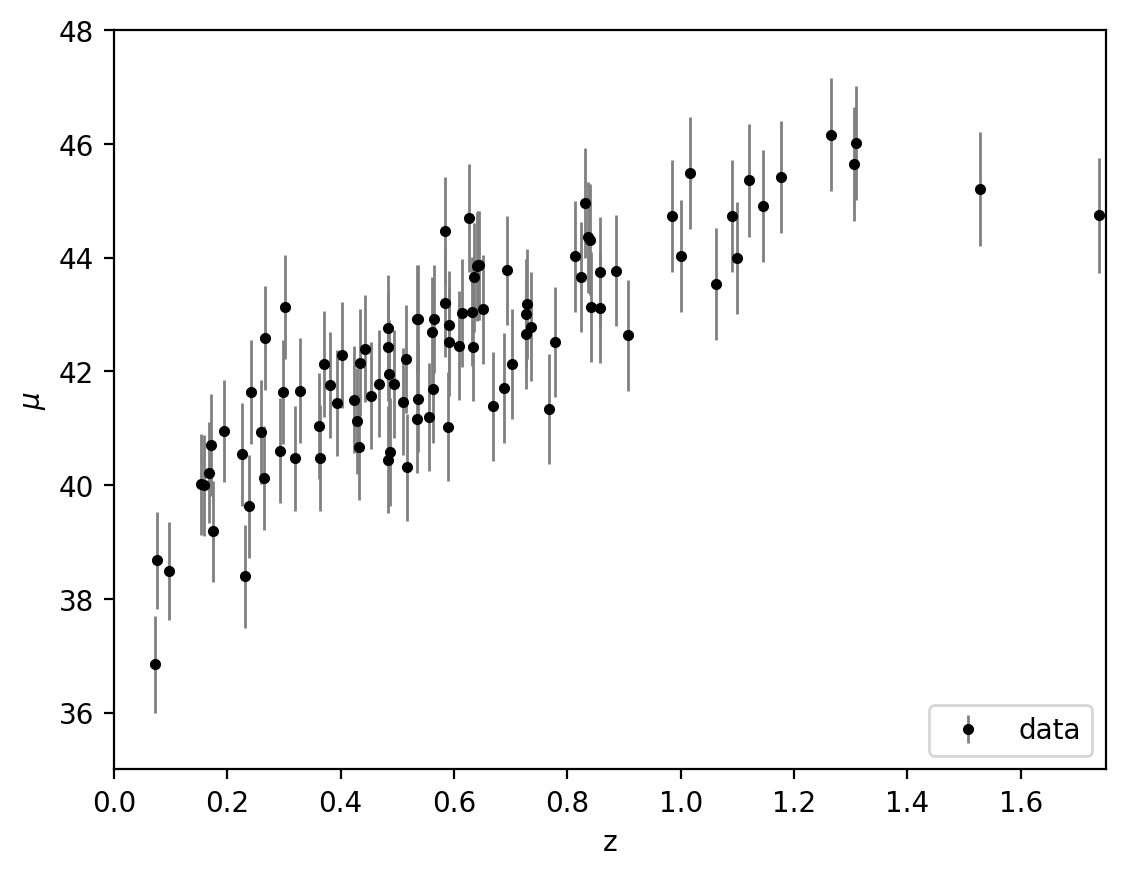

In [2]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,1.75)
plt.ylim(35,48);

I want to fit data using GaussianProcessRegressor

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from sklearn.gaussian_process.kernels import RBF

In [4]:
x = z_sample.reshape(-1, 1)
y = mu_sample.reshape(-1, 1)
dy = dmu.reshape(-1, 1)

GPR: I have to pick the kernel (naive guess)

In [5]:
kernel = 1.0 * kernels.RBF(1.0) # constant + rbf kernel (the RBF kernel is a stationary kernel. It is also known as the “squared exponential” kernel)

GPR = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2)
GPR.fit(x,y)

x_grid=np.linspace(0, 2, 1000)
y_pred, dy_pred = GPR.predict(x_grid.reshape(-1,1), return_std=True)

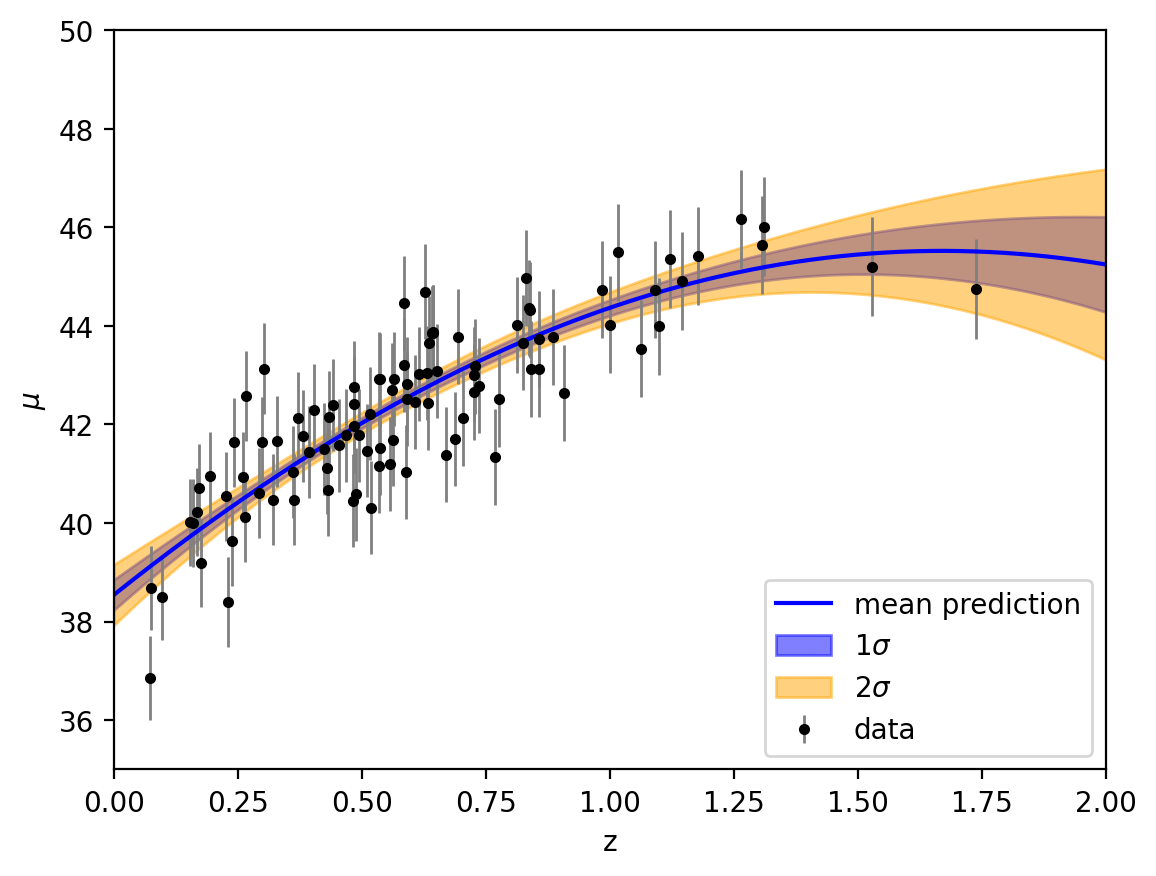

In [6]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(x_grid,y_pred, c='blue', label='mean prediction')
plt.fill_between(x_grid, y_pred-dy_pred, y_pred+dy_pred, color='blue', alpha=0.5, label=r'1$\sigma$')
plt.fill_between(x_grid, y_pred - 2 * dy_pred, y_pred + 2 * dy_pred, color='orange', alpha=0.5, label=r'2$\sigma$')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

In regions with less data the uncertainties are wider, meaning that the fit is poorly constrained.

Cloning data

First I want an estimate of the redshifts pdf, so I use KDE (naive guess on the bandwidth)

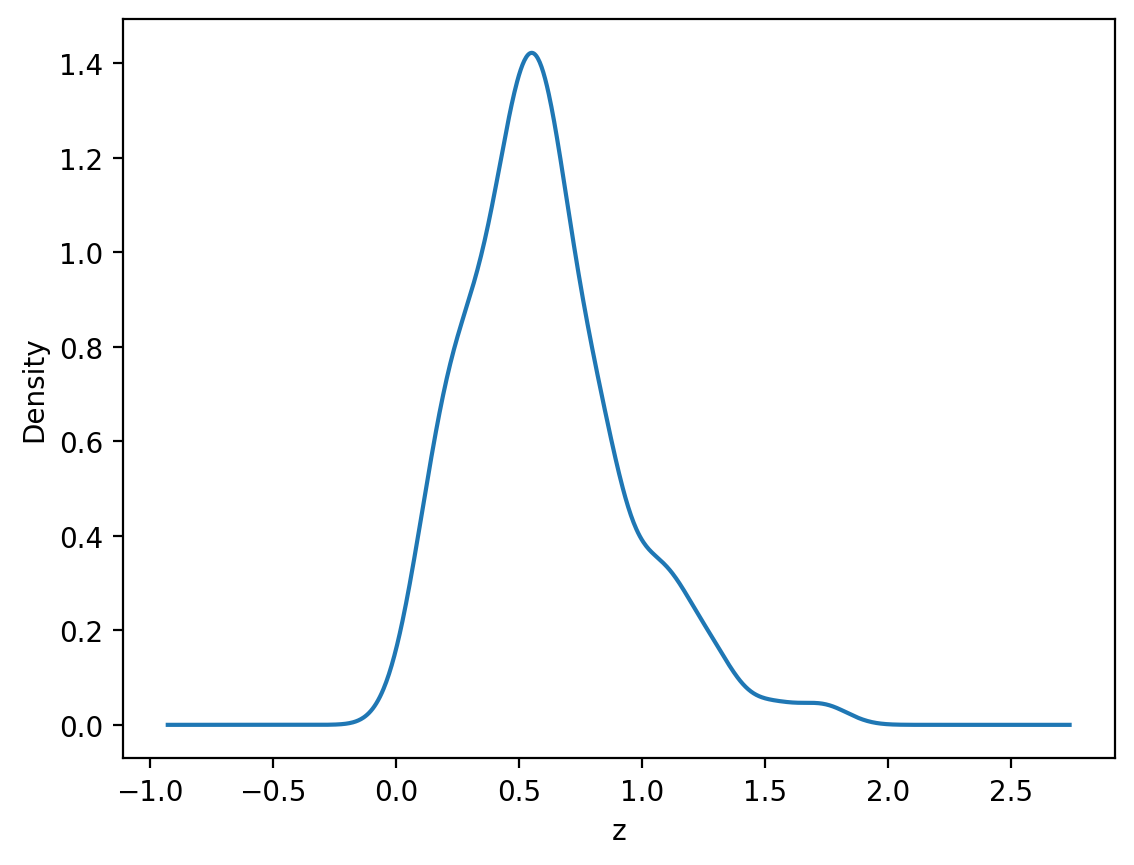

In [7]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(x)

x_plot = np.linspace(x.min() - 1, x.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(x_plot.reshape(-1,1))
dens = np.exp(log_dens)

plt.plot(x_plot[:, 0], dens)
#plt.plot(x_grid, dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

Then I take redshift samples from distribution obtained with KDE and use them to compute magnitudes using GPR fit

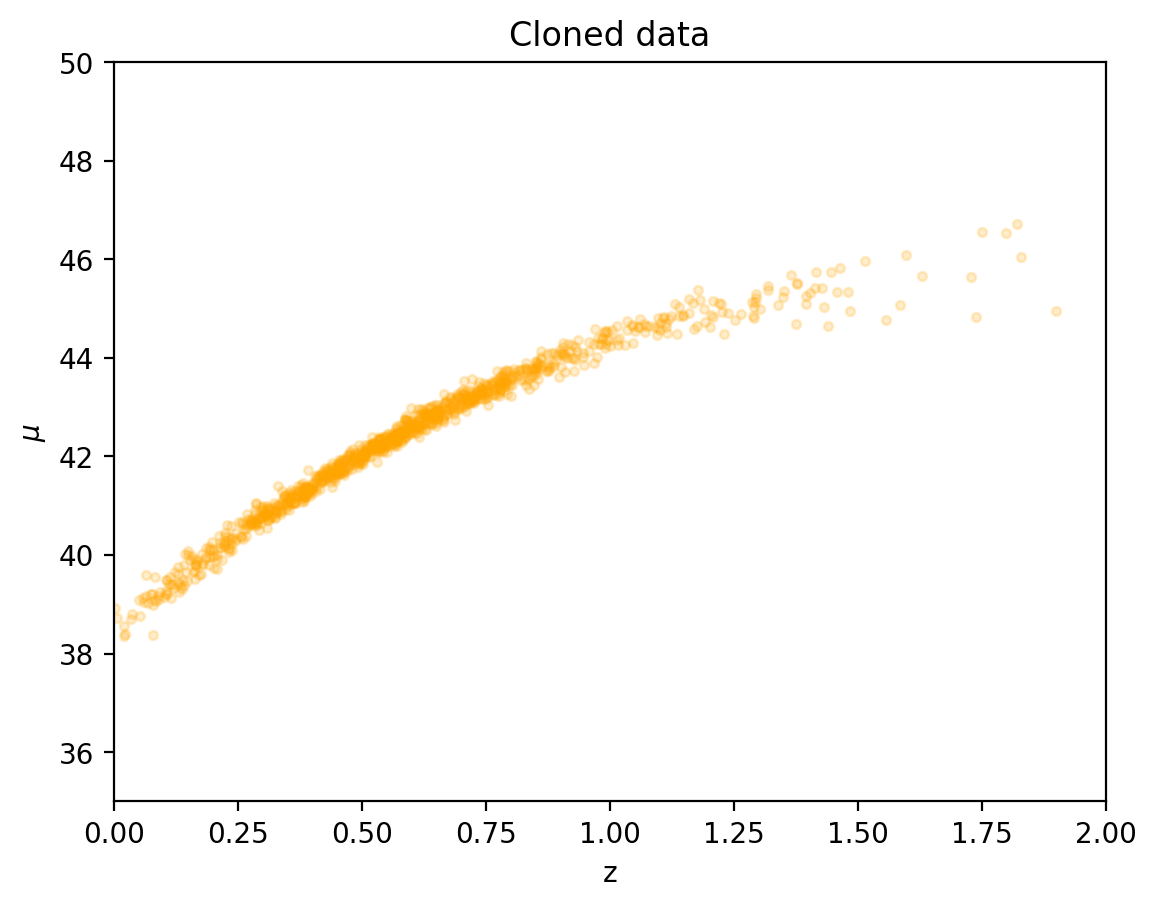

In [8]:
new_z = kde.sample(1000)

new_mu=[]
for z in np.squeeze(new_z):    
    mu_fit, sigma_fit = GPR.predict([[z]], return_std=True)
    new_mu.append(np.random.normal(loc=mu_fit,scale=sigma_fit))
    
    
plt.scatter(new_z,new_mu,s=10,alpha=0.2,color='orange')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.title("Cloned data");

Then I try fitting my new cloned data

In [9]:
kernel = 1.0 * kernels.RBF(1.0) # constant + rbf kernel

dmu=2
GPR = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2)
GPR.fit(new_z,new_mu)

x_grid=np.linspace(0, 2, 1000)
y_pred, dy_pred = GPR.predict(x_grid.reshape(-1,1), return_std=True)

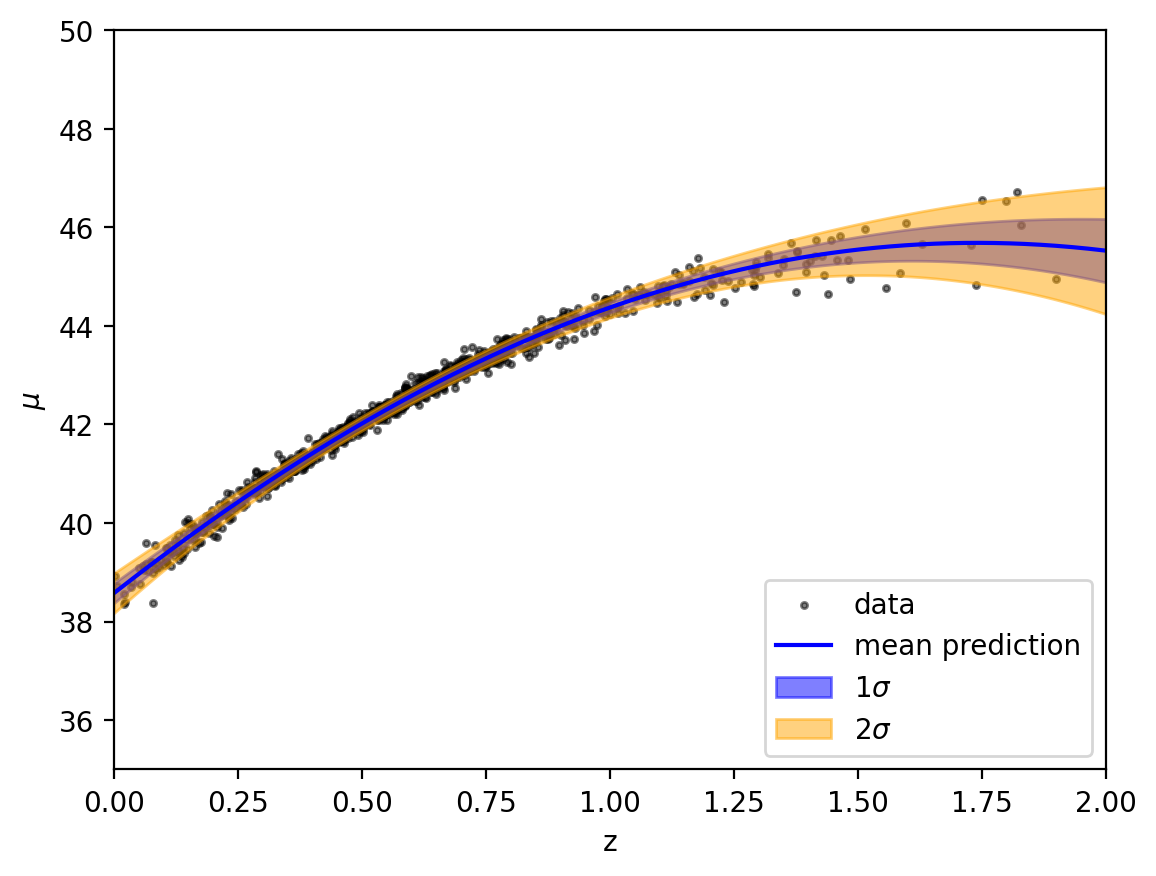

In [10]:
plt.scatter(new_z, new_mu, color='black', alpha=0.5, s=5,label='data')
plt.plot(x_grid,y_pred, c='blue', label='mean prediction')
plt.fill_between(x_grid, y_pred-dy_pred, y_pred+dy_pred, color='blue', alpha=0.5, label=r'1$\sigma$')
plt.fill_between(x_grid, y_pred - 2 * dy_pred, y_pred + 2 * dy_pred, color='orange', alpha=0.5, label=r'2$\sigma$')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

It seems (just by eye) that uncertainties are less wide, which could have been exctected since I am using now more points to train the GPR

# Part 3

In [11]:
import emcee
import scipy.stats as scistats
import corner
import dynesty

from astropy.cosmology import LambdaCDM
from astroML.datasets import generate_mu_z

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict

I want to perform parameter estimation. I write the predicted relationship (model) between redshift and distance, according to LambdaCDM cosmology 

Parameters are:
- H0 Hubble constant
- Omega_matter (and Omega_DarkEnergy = 1 - Om): in this case this is assumed to be ≠1

First I will use MCMC (emcee)

In [12]:
def model(z, H0, Om):
    cosmology = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om)
    return cosmology.distmod(z).value

def LogLikelihood(par): #gaussian likelihood
    Om,H0 = par    
    if Om<0:
        return -np.inf
    else:
        mu_model = model(z_sample, H0, Om)
    
    return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))

def Logprior(par):
    Om,H0 = par
    if 50 < H0 < 100 and 0.1 < Om < 1:
        return 0.0
    return -np.inf

                   
def LogPosterior(par):
    return LogLikelihood(par) + Logprior(par)


In [13]:
ndim = 2  # number of parameters in the model
nwalkers = 5  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take **for each walker**

starting_guesses = np.array([0.5,80]) + 1e-1* np.random.randn(nwalkers, ndim)


print(starting_guesses.shape)

(5, 2)


In [14]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(starting_guesses, nsteps)

print("done")

done


In [15]:
samples = sampler.get_chain()
tau = sampler.get_autocorr_time()
print('autocorrelation time_', tau)
print('samples shape:', samples.shape)
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)
print('flat_samples shape:', flat_samples.shape)

autocorrelation time_ [50.65446556 52.56964334]
samples shape: (10000, 5, 2)
flat_samples shape: (945, 2)


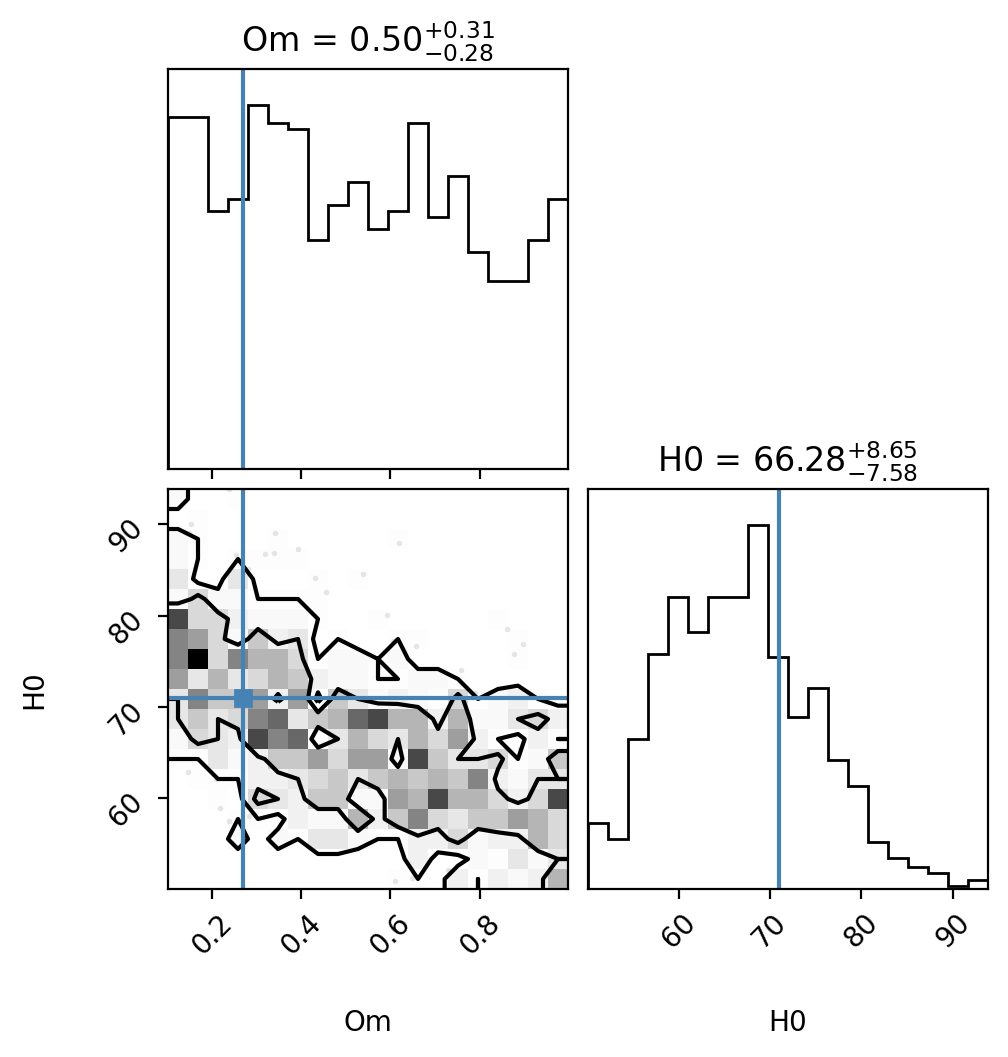

In [16]:
fig = corner.corner(flat_samples, labels=["Om","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71]);

The corner plot shows correlation between the two parameters recovered.

Take 100 samples of H0 and Om and plot the corresponding models over our data

(35.0, 50.0)

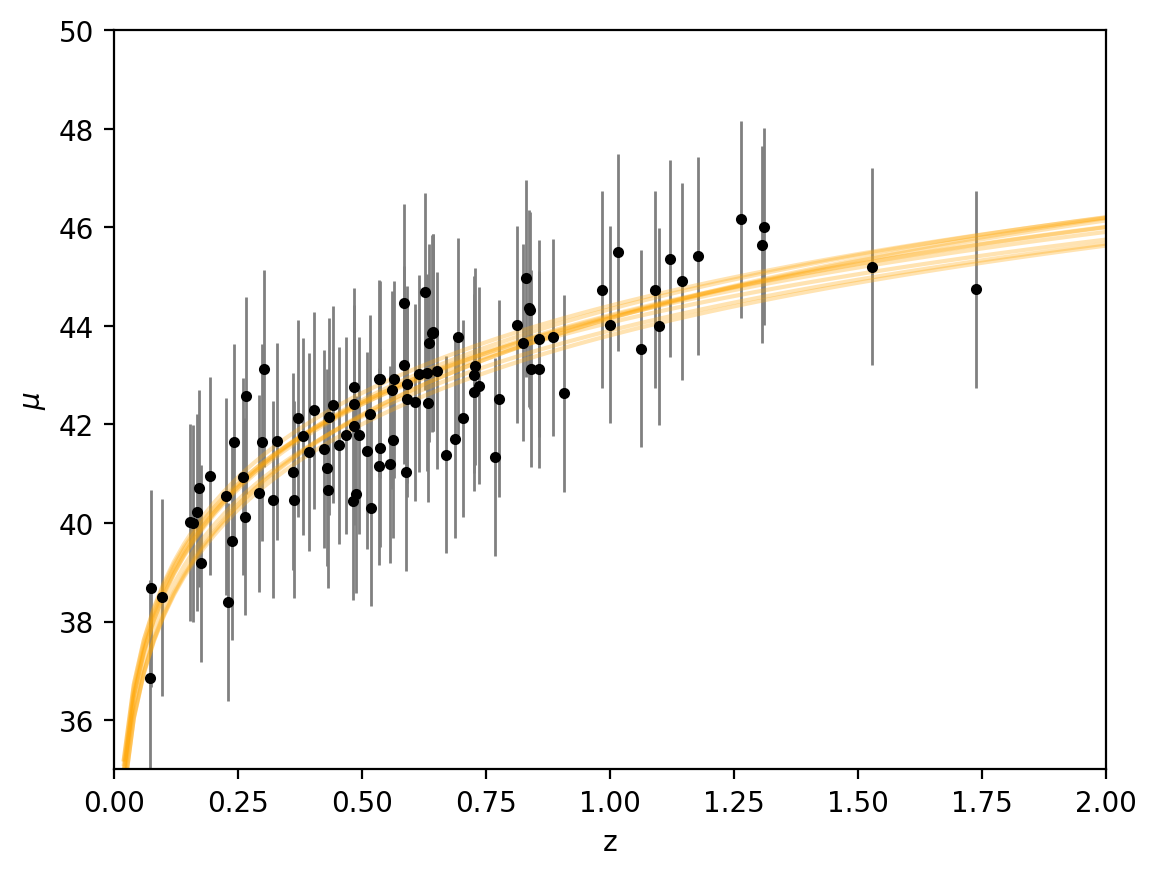

In [17]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')


zlin = np.linspace(0,2,100)[1:]
for Om,H0, in flat_samples[::100]:
    plt.plot(zlin, model(zlin, H0, Om),c='orange',alpha=0.3)

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)

Now I use NestedSampling because I want to perform model selection: I will compare the model with dark energy and the model without dark energy to see wether data contain evidence of DE

In [18]:
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc

import scipy

In [19]:
def LogLikelihood(par, z_sample, mu_sample, dmu):
    H0, Om = par
    if Om > 0:
        mu_model = model(z_sample, H0, Om)
        gauss = scipy.stats.norm(loc=mu_model, scale=dmu)
        return np.sum(gauss.logpdf(mu_sample))
    else:
        return -np.inf

def prior_transform(u):
    par = np.zeros(len(u))
    par_min = np.array([30, 0.1])
    par_max = np.array([100, 1])

    par[0] = scipy.stats.uniform(loc=par_min[0], scale=par_max[0]-par_min[0]).ppf(u[0])
    par[1] = scipy.stats.uniform(loc=par_min[1], scale=par_max[1]-par_min[1]).ppf(u[1])
    
    return par

In [20]:
ndim = 2             # number of parameters in the model

sampler = dynesty.NestedSampler(LogLikelihood, prior_transform, ndim, logl_args=[z_sample, mu_sample, dmu], nlive=200)

sampler.run_nested()
sresults = sampler.results

659it [00:24, 26.43it/s, +200 | bound: 0 | nc: 1 | ncall: 5526 | eff(%): 16.128 | loglstar:   -inf < -171.561 <    inf | logz: -173.185 +/-  0.059 | dlogz:  0.001 >  0.209]


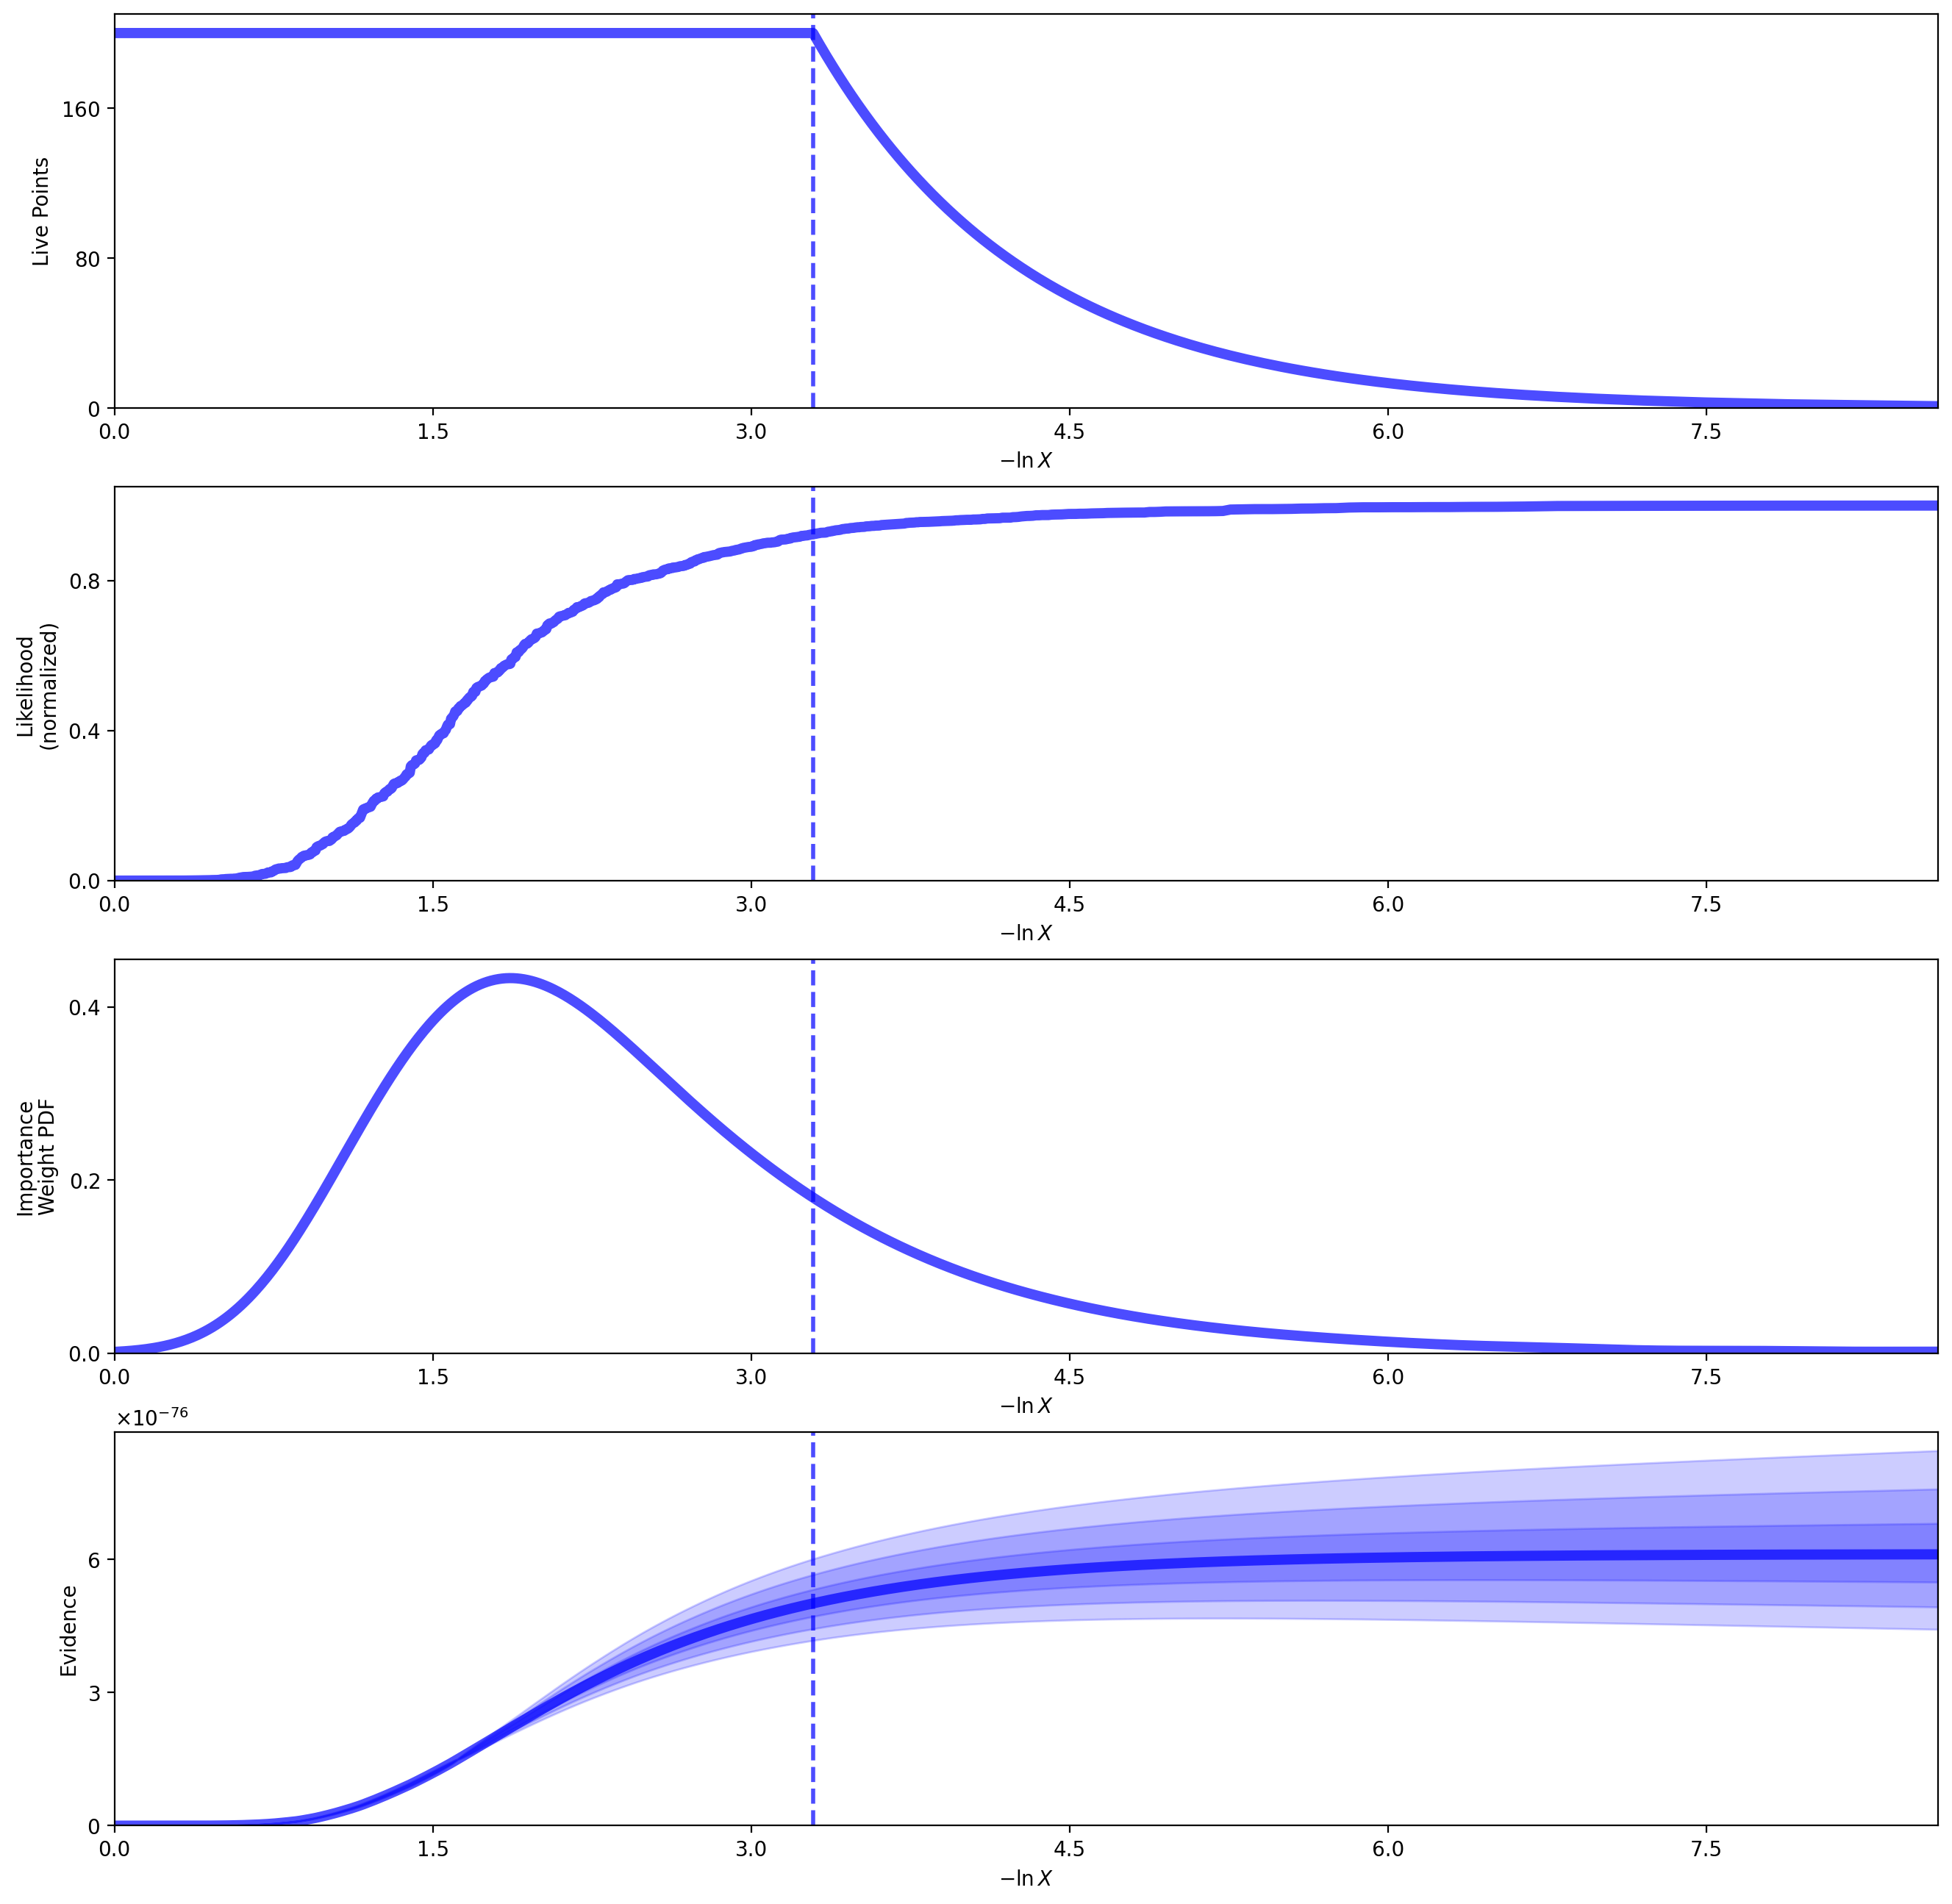

In [21]:
runplot_fig, runplot_axes = dyplot.runplot(sresults)

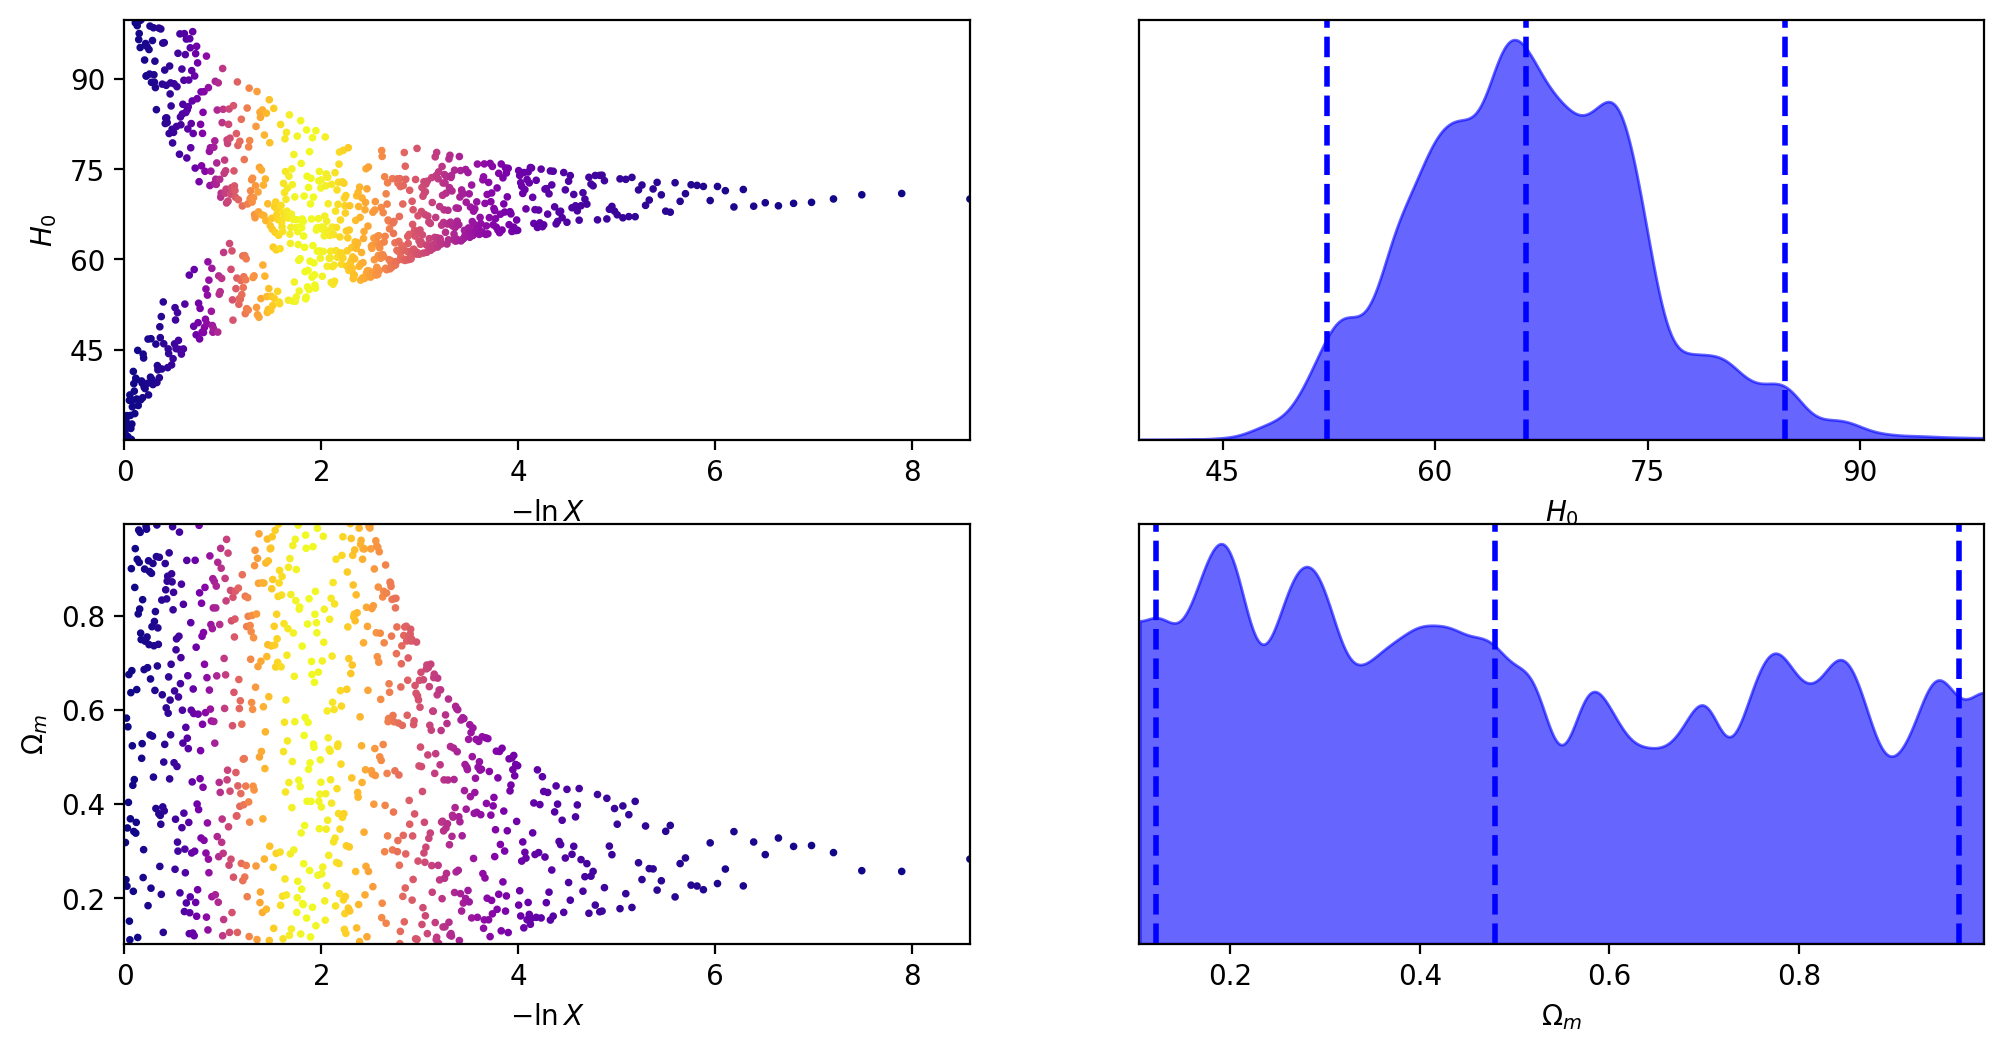

In [22]:
labels = ["$H_0$", "$\\Omega_m$"]
traceplot_fig, traceplot_axes = dyplot.traceplot(sresults, labels=labels)

In [23]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

In [24]:
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

68% parameter credible regions are:
 [[58.784761445284964, 73.92217109535645], [0.21255422305689872, 0.836553805355457]]



In [25]:
samples_equal = dyfunc.resample_equal(samples, weights)

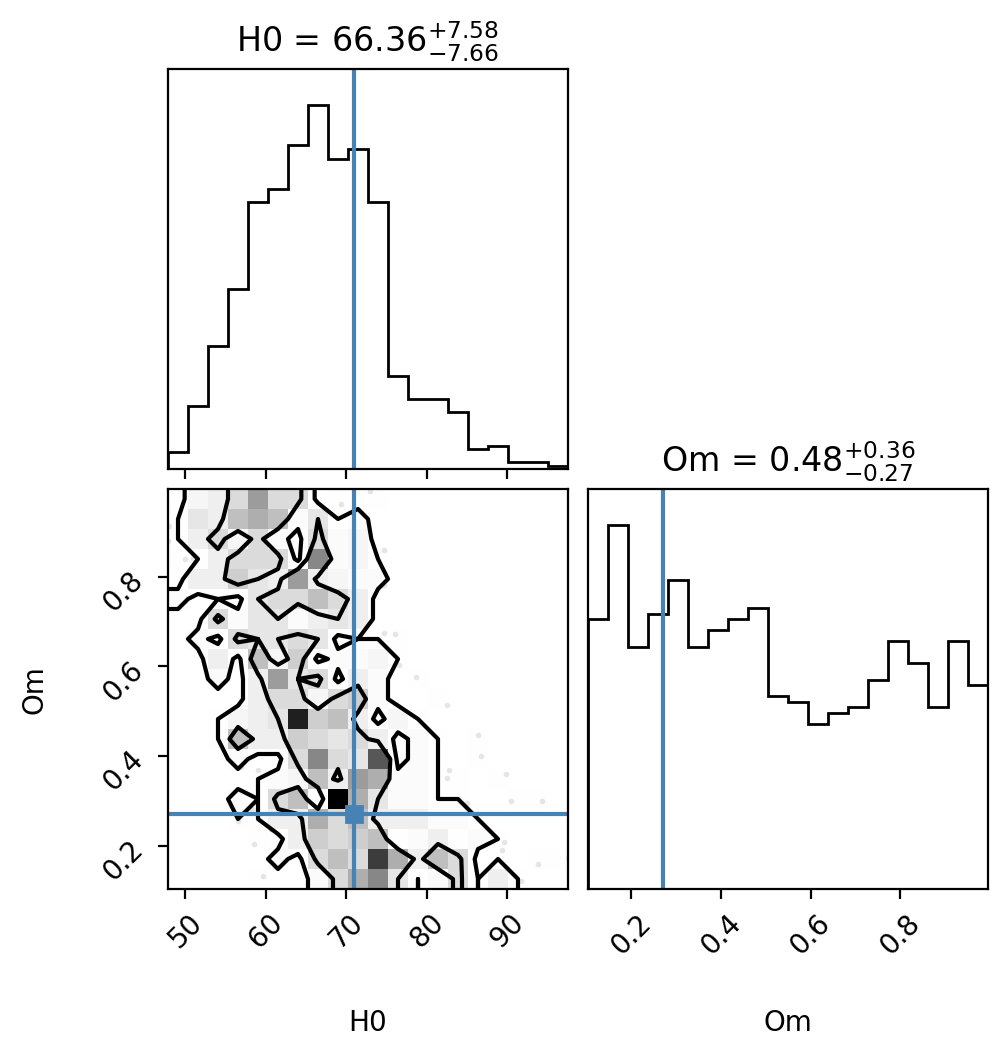

In [26]:
fig = corner.corner(
    samples_equal, labels=["H0","Om"], levels=[0.68,0.95], show_titles=True, truths=[71,0.27]
);

In [27]:
log_evidence = sresults.logz[-1]          
log_evidence_error = sresults.logzerr[-1]

evidence = np.exp(log_evidence)
print("Bayesian evidence:", evidence)
 
evidence_error = evidence * log_evidence_error
print("Bayesian evidence error:", evidence_error)

Bayesian evidence: 6.116720006586571e-76
Bayesian evidence error: 6.598487829389348e-77


Take 100 samples of H0 and Om and plot the corresponding models over our data

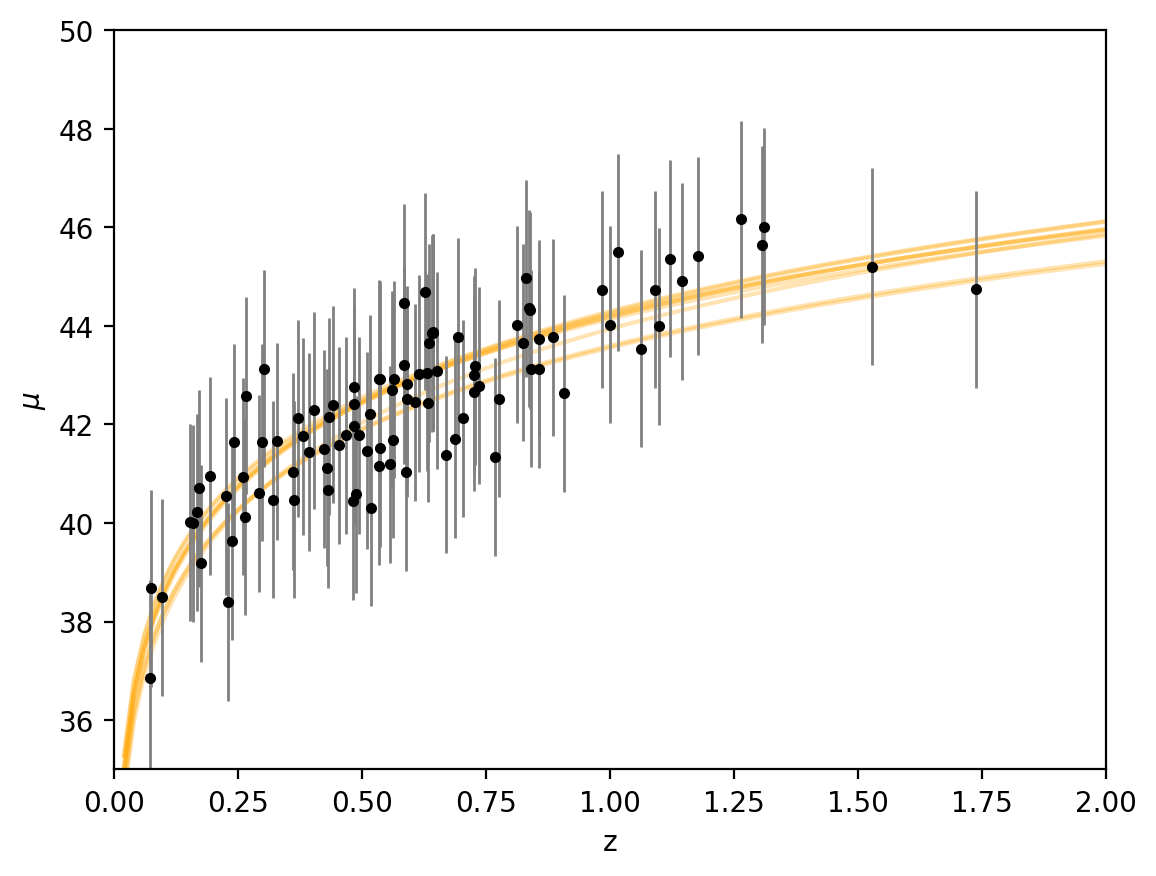

In [28]:
samples_equal = dyfunc.resample_equal(samples, weights)

for H0,Om in samples_equal[::100]:
    plt.plot(zlin, model(zlin, H0, Om),c='orange',alpha=0.3)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

I use NestedSampling for a model without dark energy (Om=1, Ode=0): in this case H0 is the only parameter

In [29]:
def LogLikelihood_mod(par):

    H0 = float(par[0])    
    Om=1
    mu_model = model(z_sample, H0, Om)
    return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))

ndim  =1

def ptform(u):
    """Transforms samples `u` drawn from the unit cube to samples to those
    from our uniform prior within [-10., 10.) for each variable."""
    mins = np.array([30.])
    maxs = np.array([100.])
        
    return  mins + u*(maxs-mins)

In [30]:
# "Static" nested sampling.
sampler_mod = dynesty.NestedSampler(LogLikelihood_mod, ptform, ndim,nlive=1000)
sampler_mod.run_nested()
sresults_mod = sampler_mod.results

1990it [00:16, 123.25it/s, +1000 | bound: 0 | nc: 1 | ncall: 8431 | eff(%): 40.237 | loglstar:   -inf < -171.773 <    inf | logz: -173.383 +/-    nan | dlogz:  0.001 >  1.009]


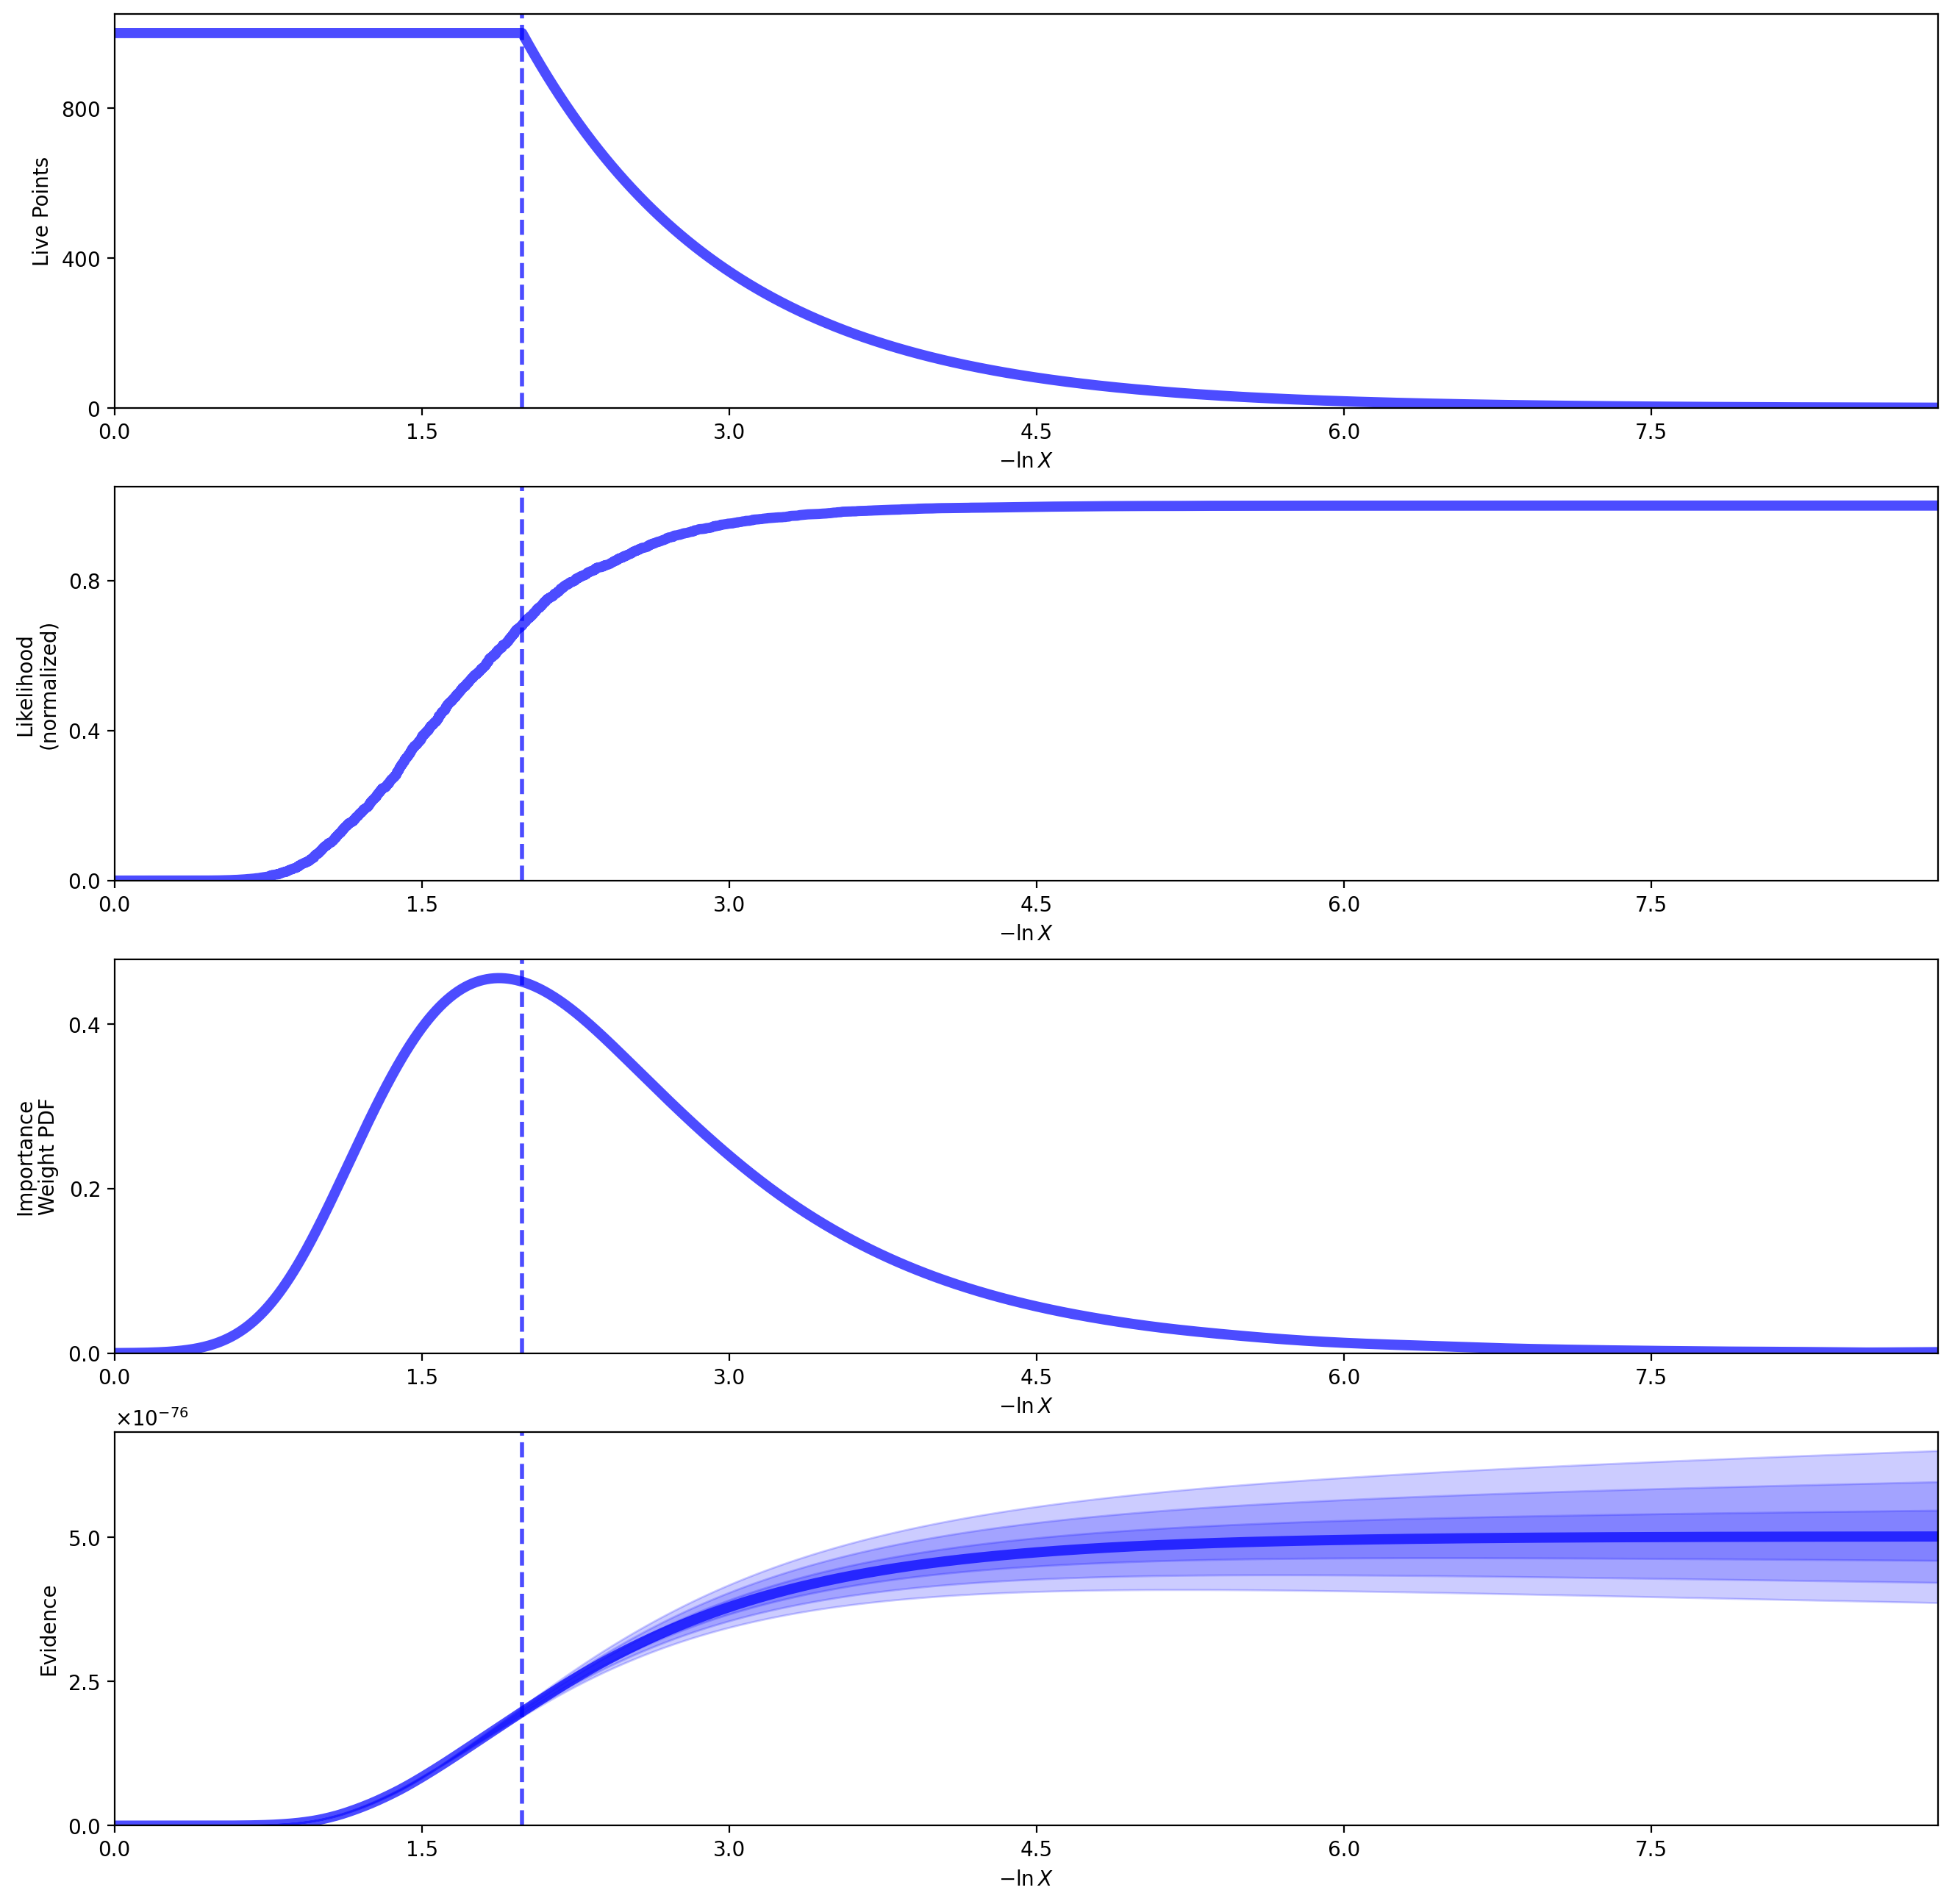

In [31]:
runplot_fig, runplot_axes = dyplot.runplot(sresults_mod)

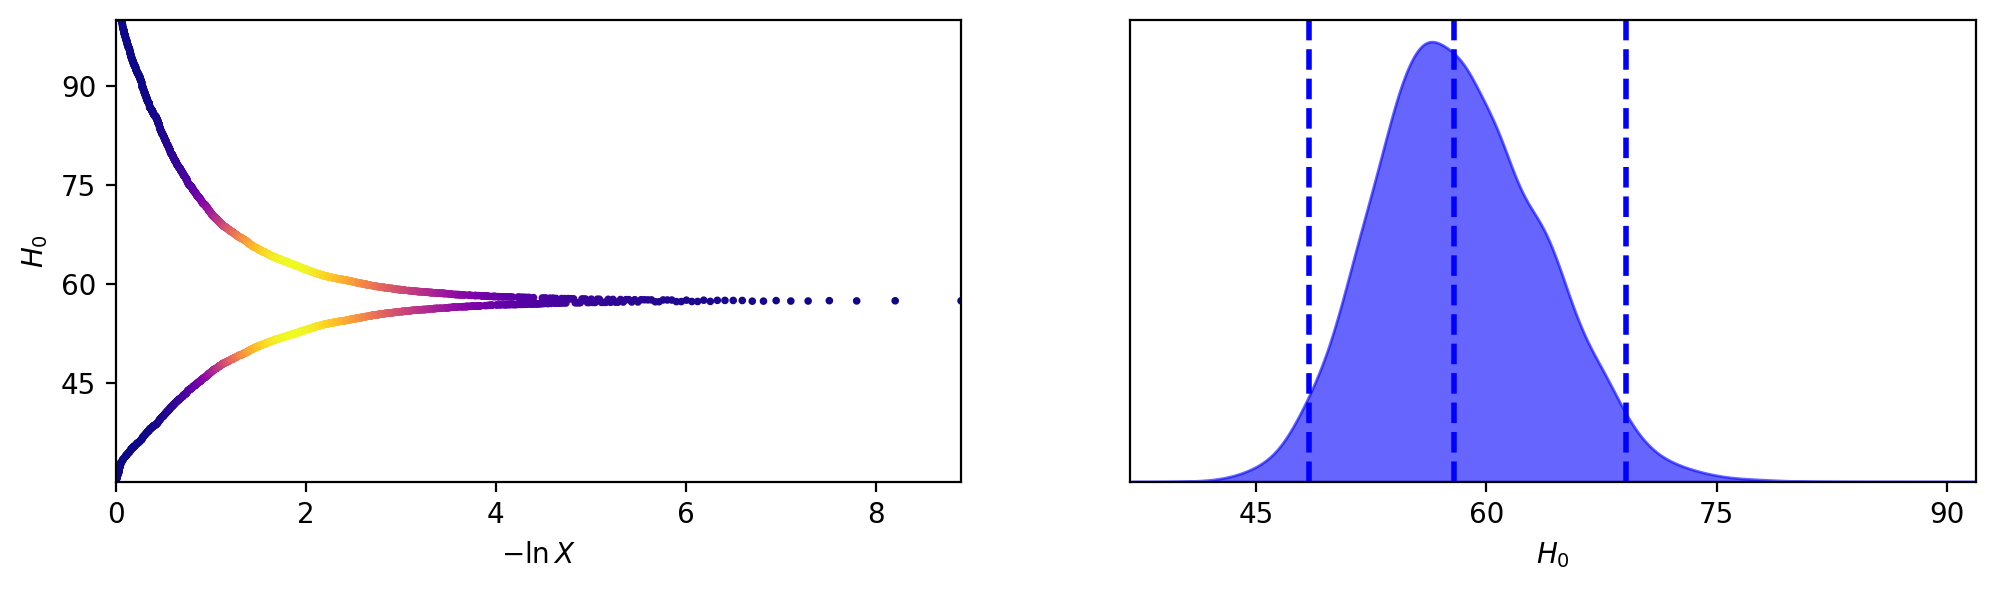

In [32]:
labels = ["$H_0$"]
traceplot_fig, traceplot_axes = dyplot.traceplot(sresults_mod, labels=labels)

In [33]:
# Extract sampling results.
samples = sresults_mod.samples  # samples
weights = np.exp(sresults_mod.logwt - sresults_mod.logz[-1])  # normalized weights

In [34]:
quantiles = [dyfunc.quantile(samps, [0.16, 0.84], weights=weights)
             for samps in samples.T]
print('68% parameter credible regions are:\n ' + str(quantiles) + '\n')

68% parameter credible regions are:
 [[52.822981370379544, 63.74980325069174]]



In [35]:
samples_equal_mod = dyfunc.resample_equal(samples, weights)

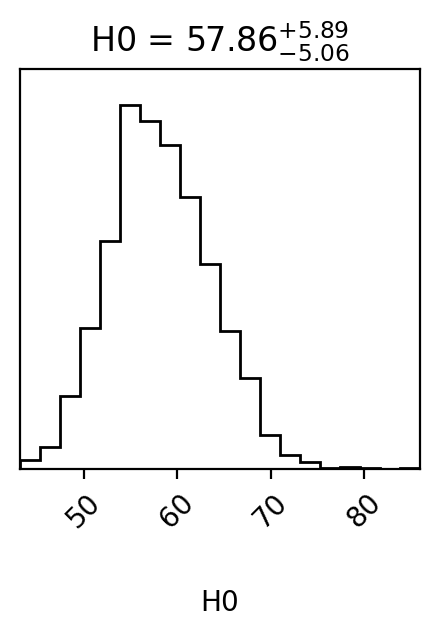

In [36]:
corner.corner(samples_equal_mod, labels=["H0"], levels=[0.68,0.95], show_titles=True);

In [37]:
log_evidence_noDM = sresults_mod.logz[-1]          
log_evidence_error_noDM = sresults_mod.logzerr[-1]

evidence_noDM = np.exp(log_evidence_noDM)
print("Bayesian evidence:", evidence_noDM)

evidence_error_noDM = evidence_noDM * log_evidence_error_noDM
print("Bayesian evidence error:", evidence_error_noDM)

Bayesian evidence: 5.01802905567825e-76
Bayesian evidence error: 4.347501515388156e-77


Take 100 samples of H0 and Om and plot the corresponding models over our data

(35.0, 50.0)

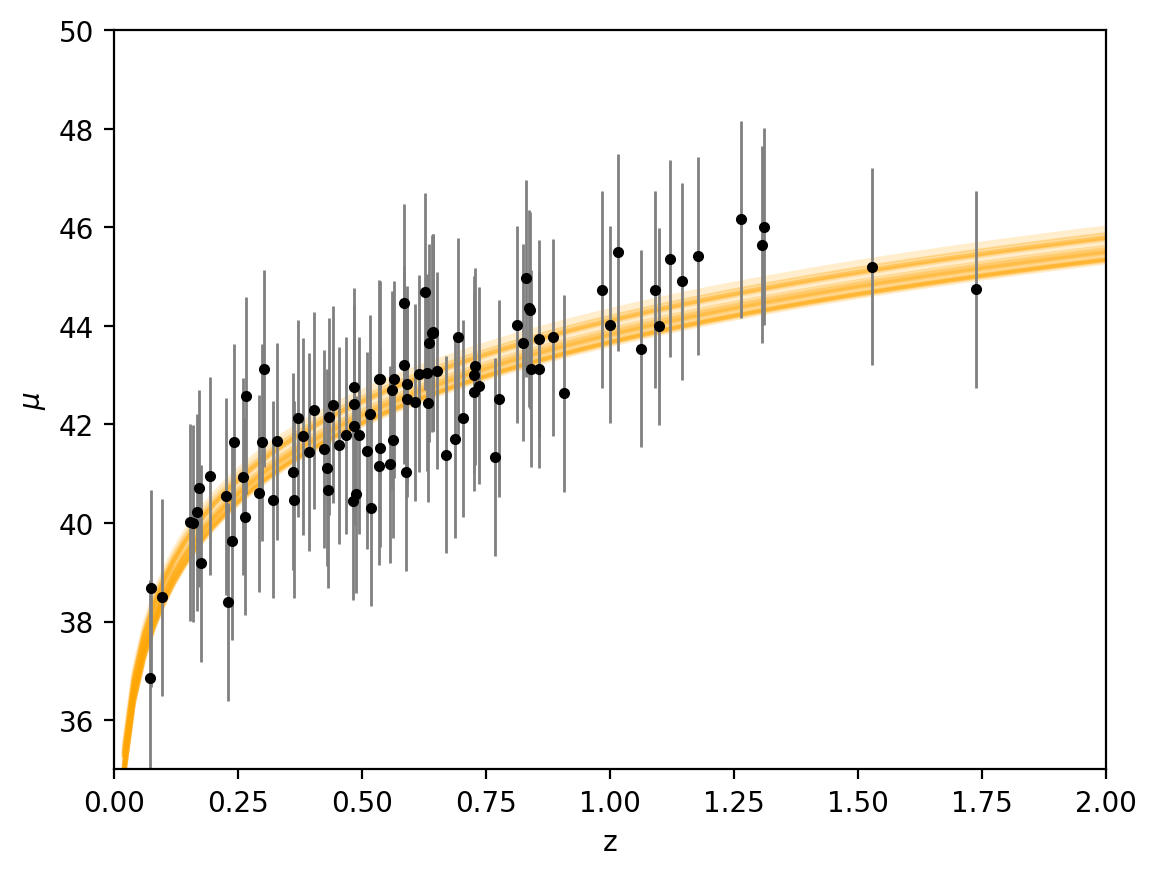

In [38]:
for H0 in samples_equal_mod[::100]:
    plt.plot(zlin, model(zlin, float(H0[0]), 1),c='orange',alpha=0.2)
    
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)

odds ratio to compare the two models (with and without DE)

In [39]:
np.exp(sampler.results.logz[-1])/np.exp(sampler_mod.results.logz[-1])

1.2189487025120103

"Barely worth mentioning"

With this data we can't tell if the universe has (H0 ~ 66 ; Om ~ 0.48) or (H0 ~ 60 ; Om ~ 1)